# Exercise 1. 1D Velocity Integration

This notebook solves Exercise 1 of NX-465 Mini-project 2, using the 1D ring-attractor kernel from Exercise 0 as the recurrent connectivity building block.

The model has two sub-populations on the same ring of $M=100$ neurons:

- a right-shifting population $R$, whose outgoing kernel is $W_R(x-x') = W(x-x'-l)$;
- a left-shifting population $L$, whose outgoing kernel is $W_L(x-x') = W(x-x'+l)$.

Both populations receive the same recurrent input, but different velocity-modulated tonic inputs:

$$
B_R(t)=B_0(1+\alpha v(t)), \qquad B_L(t)=B_0(1-\alpha v(t)).
$$

Unless stated otherwise, I use $B_0=1.5$, $\alpha=0.5$, $l=1.0$, $\tau=10\,\mathrm{ms}$, and $\Delta t=1\,\mathrm{ms}$, as requested.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))
(PROJECT_ROOT / ".matplotlib").mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt

from helper import (
    IntegratorParams,
    TwoPopulationVelocityIntegrator,
    dominant_spatial_frequency,
    estimate_segment_velocities,
    fourier_bump_position,
    linear_fit,
    sampled_velocity_protocol,
    step_velocity_protocol,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1.1. Step Velocity Simulation

For the first simulation, I keep the velocity at $v=0$ for 300 ms to allow the spontaneous bump pattern to stabilize. Then I apply a constant positive velocity $v=1.0$ from 300 ms to 700 ms, followed again by $v=0$.

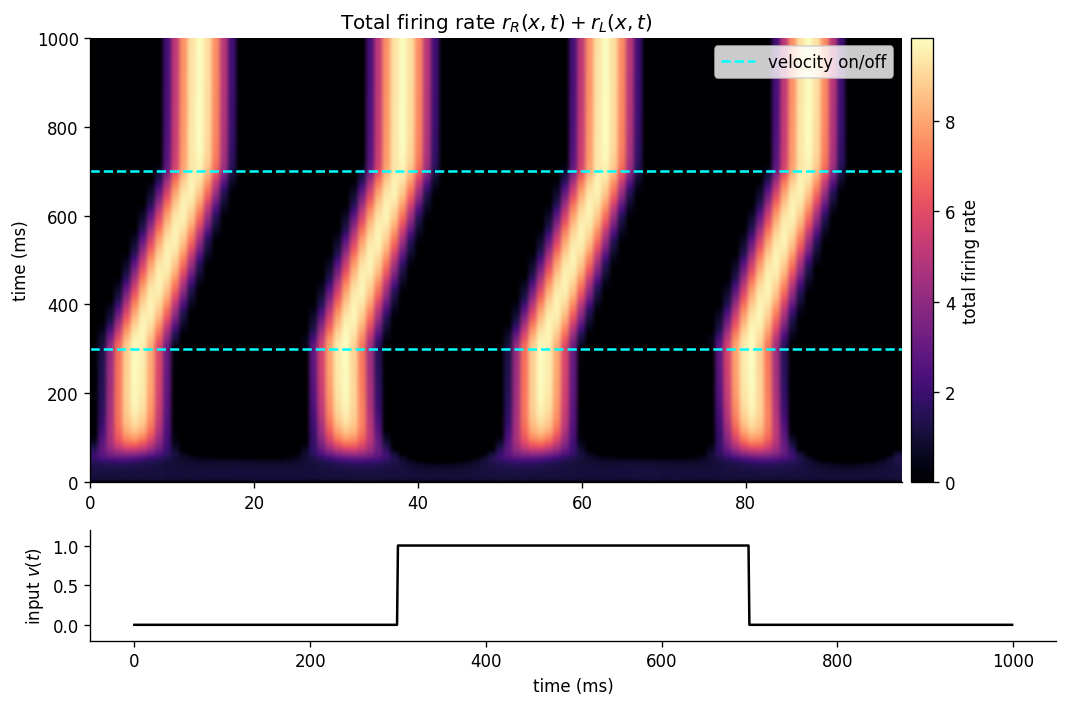

In [2]:
params = IntegratorParams()
model = TwoPopulationVelocityIntegrator(params)

velocity_step = step_velocity_protocol(
    total_steps=1000,
    moving_start=300,
    moving_end=700,
    velocity_value=1.0,
)
result_step = model.simulate(velocity_step, seed=1)
rate_total_step = result_step["rate_total"]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    sharex=False,
    gridspec_kw={"height_ratios": [4, 1]},
)

im = axes[0].imshow(
    rate_total_step,
    aspect="auto",
    origin="lower",
    cmap="magma",
    extent=[0, params.m - 1, 0, len(velocity_step)],
)
axes[0].axhline(300, color="cyan", linestyle="--", linewidth=1.5, label="velocity on/off")
axes[0].axhline(700, color="cyan", linestyle="--", linewidth=1.5)
axes[0].set_ylabel("time (ms)")
axes[0].set_title("Total firing rate $r_R(x,t)+r_L(x,t)$")
axes[0].legend(loc="upper right")
cbar = fig.colorbar(im, ax=axes[0], pad=0.01)
cbar.set_label("total firing rate")

axes[1].plot(velocity_step, color="black")
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("input $v(t)$")
axes[1].set_ylim(-0.2, 1.2)

fig.tight_layout()
plt.show()

**Answer to 1.1.** The network first forms a stable periodic bump pattern on the ring. During the interval where $v=1$, the full pattern translates coherently around the ring: the bright bands become slanted in the heat map. Once the velocity is set back to zero, the same activity pattern stops translating and becomes stationary again. This is the qualitative behavior expected from a velocity integrator.

## 1.2. Why Asymmetric Inputs Move the Bump

The two populations have shifted outgoing kernels. Activity in the $R$ population projects through a kernel shifted in one direction, while activity in the $L$ population projects through a kernel shifted in the opposite direction. When $v=0$, both populations receive the same tonic input, so their opposite shifts balance and the bump remains stationary.

For $v>0$, $B_R=B_0(1+\alpha v)$ is larger and $B_L=B_0(1-\alpha v)$ is smaller. This gives more influence to the right-shifted recurrent drive than to the left-shifted recurrent drive. The recurrent input peak is therefore slightly displaced relative to the current activity peak. The network relaxes toward this displaced input peak, so the bump moves continuously. For $v<0$, the asymmetry reverses and the bump moves in the opposite direction.

Thus the velocity signal is not injected as a direct displacement. It changes the relative gain of two oppositely shifted recurrent streams, which turns a static attractor into a moving attractor.

## 1.3. Varying Velocity Magnitudes

I next sample ten velocities from $[-2,-0.5]\cup[0.5,2]$. I again use 300 ms of $v=0$ warm-up, then hold each sampled velocity for 300 ms.

Sampled velocities:
  segment 01: v = +0.508
  segment 02: v = -1.732
  segment 03: v = +1.696
  segment 04: v = -1.202
  segment 05: v = -0.955
  segment 06: v = +0.918
  segment 07: v = -0.882
  segment 08: v = -1.168
  segment 09: v = +1.257
  segment 10: v = +1.330


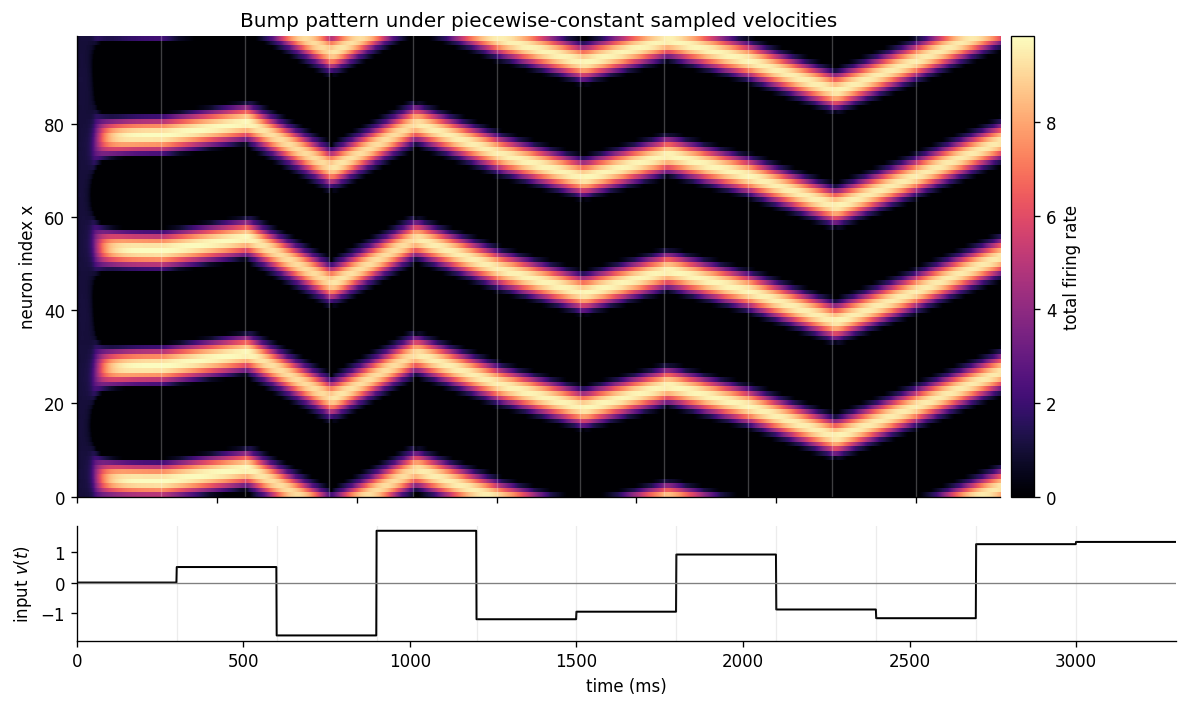

In [3]:
velocity_var, sampled_velocities, segment_starts = sampled_velocity_protocol(
    seed=7,
    n_velocities=10,
    segment_steps=300,
    warmup_steps=300,
)
result_var = model.simulate(velocity_var, seed=2)
rate_total_var = result_var["rate_total"]

time = np.arange(len(velocity_var))

print("Sampled velocities:")
for i, v in enumerate(sampled_velocities, start=1):
    print(f"  segment {i:02d}: v = {v:+.3f}")

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]},
)

im = axes[0].imshow(
    rate_total_var.T,
    aspect="auto",
    origin="lower",
    cmap="magma",
    extent=[0, len(velocity_var), 0, params.m - 1],
    interpolation="nearest",
)
for start in segment_starts:
    axes[0].axvline(start, color="white", alpha=0.25, linewidth=0.8)
axes[0].set_ylabel("neuron index x")
axes[0].set_title("Bump pattern under piecewise-constant sampled velocities")
cbar = fig.colorbar(im, ax=axes[0], pad=0.01)
cbar.set_label("total firing rate")

axes[1].plot(time, velocity_var, color="black", linewidth=1.2)
axes[1].axhline(0, color="gray", linewidth=0.8)
for start in segment_starts:
    axes[1].axvline(start, color="gray", alpha=0.15, linewidth=0.8)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("input $v(t)$")
axes[1].set_xlim(0, len(velocity_var))

fig.tight_layout()
plt.show()

## 1.4. Measuring Bump Velocity

Because the pattern can contain several periodically repeated bumps, a simple center of mass on the ring can be unstable or ambiguous. I therefore estimate the bump position using the phase of the dominant spatial Fourier mode.

For activity $r(x,t)$, let $k$ be the strongest non-zero spatial Fourier mode after stabilization, and define:

$$
c_k(t)=\sum_x \left(r(x,t)-\bar r(t)\right)e^{-2\pi i kx/M}.
$$

If the whole pattern shifts by $\Delta x$, the phase of $c_k$ changes by $-2\pi k\Delta x/M$. After phase unwrapping, this gives a continuous displacement trace:

$$
\hat x(t)=-\frac{M}{2\pi k}\mathrm{unwrap}\left(\arg c_k(t)\right).
$$

I estimate bump velocity in each 300 ms segment by fitting a line to $\hat x(t)$, discarding the first 50 ms of each segment to reduce transition effects.

Dominant spatial mode used for phase tracking: k = 4
Linear fit: bump_velocity = 0.0187 * input_velocity + 0.0000
R^2 = 0.9994

input velocity -> measured bump velocity (neurons/ms)
+0.508 -> +0.0091
-1.732 -> -0.0334
+1.696 -> +0.0326
-1.202 -> -0.0222
-0.955 -> -0.0173
+0.918 -> +0.0166
-0.882 -> -0.0159
-1.168 -> -0.0215
+1.257 -> +0.0233
+1.330 -> +0.0248


/Users/guhaotian/Desktop/Computational Neuroscience/project/nx-465-mini-proj/helper.py:186: RuntimeWarning: divide by zero encountered in matmul
  coeff = centered @ basis
/Users/guhaotian/Desktop/Computational Neuroscience/project/nx-465-mini-proj/helper.py:186: RuntimeWarning: overflow encountered in matmul
  coeff = centered @ basis
/Users/guhaotian/Desktop/Computational Neuroscience/project/nx-465-mini-proj/helper.py:186: RuntimeWarning: invalid value encountered in matmul
  coeff = centered @ basis


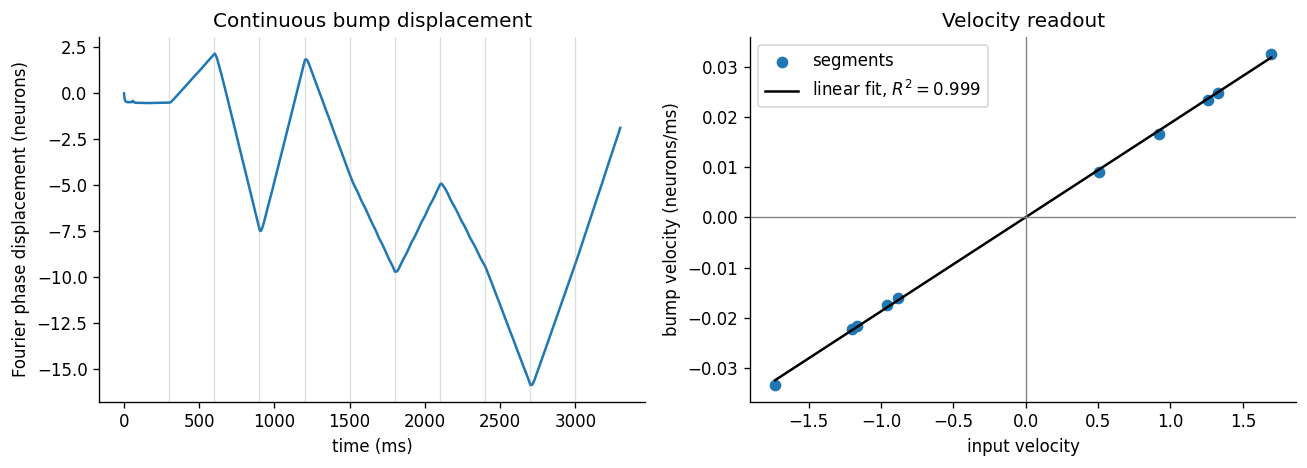

In [4]:
k = dominant_spatial_frequency(rate_total_var, window=slice(250, 300))
position, used_k = fourier_bump_position(rate_total_var, k=k)
estimated_bump_velocities = estimate_segment_velocities(
    position,
    segment_starts=segment_starts,
    segment_steps=300,
    discard_steps=50,
    dt_ms=params.dt_ms,
)
slope, intercept, r_squared = linear_fit(sampled_velocities, estimated_bump_velocities)

print(f"Dominant spatial mode used for phase tracking: k = {used_k}")
print(f"Linear fit: bump_velocity = {slope:.4f} * input_velocity + {intercept:.4f}")
print(f"R^2 = {r_squared:.4f}")
print()
print("input velocity -> measured bump velocity (neurons/ms)")
for v_in, v_bump in zip(sampled_velocities, estimated_bump_velocities):
    print(f"{v_in:+.3f} -> {v_bump:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(np.arange(len(position)), position, color="tab:blue")
for start in segment_starts:
    axes[0].axvline(start, color="gray", alpha=0.25, linewidth=0.8)
axes[0].set_xlabel("time (ms)")
axes[0].set_ylabel("Fourier phase displacement (neurons)")
axes[0].set_title("Continuous bump displacement")

axes[1].scatter(sampled_velocities, estimated_bump_velocities, color="tab:blue", label="segments")
x_fit = np.linspace(sampled_velocities.min(), sampled_velocities.max(), 100)
axes[1].plot(
    x_fit,
    slope * x_fit + intercept,
    color="black",
    linewidth=1.5,
    label=f"linear fit, $R^2={r_squared:.3f}$",
)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].axvline(0, color="gray", linewidth=0.8)
axes[1].set_xlabel("input velocity")
axes[1].set_ylabel("bump velocity (neurons/ms)")
axes[1].set_title("Velocity readout")
axes[1].legend()

fig.tight_layout()
plt.show()